In [95]:
# https://www.digikey.com/en/maker/tutorials/2024/implementing-a-pid-controller-algorithm-in-python

In [96]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import utils
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box, Discrete

import os

In [97]:
#__credits__ = ["Kallinteris-Andreas", "Rushiv Arora"]
# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/mujoco/swimmer_v5.py referenced
class ROVEnv(MujocoEnv, utils.EzPickle):

    metadata = {
        "render_modes": [
            "human",
            "rgb_array",
            "depth_array",
            "rgbd_tuple",
        ],
    }

    def __init__(
        self,
        xml_file: str = "rov.xml",
        frame_skip: int = 4,
        default_camera_config: dict[str, float | int] = None,
        distance_reward_weight: float = 1.0,
        reset_noise_scale: float = 0.1,
        **kwargs,
    ):
        utils.EzPickle.__init__(
            self,
            xml_file,
            frame_skip,
            default_camera_config,
            distance_reward_weight,
            reset_noise_scale,
            **kwargs,
        )

        self.distance_reward_weight = distance_reward_weight

        self._reset_noise_scale = reset_noise_scale

        MujocoEnv.__init__(
            self,
            xml_file,
            frame_skip,
            observation_space=None,
            default_camera_config=default_camera_config,
            **kwargs,
        )

        self.metadata = {
            "render_modes": [
                "human",
                "rgb_array",
                "depth_array",
                "rgbd_tuple",
            ],
            "render_fps": int(np.round(1.0 / self.dt)),
        }

        obs_size = 4
        
        self.observation_space = Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float64
        )

        self.observation_structure = {
            "distance_to_goal": 2,
            "velocity": 2,
        }

        self.possible_actions = {
            0: np.array([ 0,  0,  0,  0]), # stop
            1: np.array([-1,  1,  1, -1]), # left
            2: np.array([ 1, -1, -1,  1]), # right
            3: np.array([ 1,  1, 1, 1]), # forward
            4: np.array([-1, -1,  -1,  -1]), # backward
            5: np.array([ 1,  0,  0,  1]), # diagonal right forward
            6: np.array([ -1,  0,  0,  -1]), # diagonal left backward
            7: np.array([0, 1,  1,  0]), # diagonal left forward
            8: np.array([ 0,  -1,  -1,  0]), # diagonal right backward
        }

        self.action_space = Discrete(len(self.possible_actions))

        
    def step(self, action):        
        xy_position_before = self.data.qpos[0:2].copy()
        action = self.possible_actions[int(action)]
        self.do_simulation(action, self.frame_skip)
        xy_position_after = self.data.qpos[0:2].copy()

        xy_velocity = (xy_position_after - xy_position_before) / self.dt
        x_velocity, y_velocity = xy_velocity

        observation = self.get_observation()
        
        reward, reward_info = self.get_reward(xy_position_after)
        info = {
            "x_position": xy_position_after[0],
            "y_position": xy_position_after[1],
            "distance_from_origin": np.linalg.norm(xy_position_after, ord=2),
            "distance_from_goal": np.linalg.norm(observation[0:2]),
            "x_velocity": x_velocity,
            "y_velocity": y_velocity,
            **reward_info,
        }

        if self.render_mode == "human":
            self.render()

        distance_to_goal = np.linalg.norm(observation[0:2])
        if distance_to_goal < 0.5:
            terminated = True
        else:
            terminated = False

        self.step_count += 1
        if self.step_count >= 1000:
            truncated = True
        else:
            truncated = False

        return observation, reward, terminated, truncated, info

    def get_reward(self, position):
        distance_from_goal = self.goal_position - position
        distance_reward = self.distance_reward_weight * np.exp(-np.linalg.norm(distance_from_goal)**2)

        penalty = -0.1
        
        total_reward = distance_reward + penalty

        reward = total_reward

        reward_info = {
            "distance_reward": distance_reward,
            "total_reward": total_reward,
        }

        return reward, reward_info

    def get_observation(self):
        position = self.data.qpos[0:2]
        distance_to_goal = self.goal_position - position
        velocity = self.data.qvel[0:2]

        observation = np.concatenate([distance_to_goal, velocity]).ravel()
        return observation

    def reset_model(self):
        self.step_count = 0
        
        noise_low = -self._reset_noise_scale
        noise_high = self._reset_noise_scale

        qpos = self.init_qpos + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nq
        )
        qvel = self.init_qvel + self.np_random.uniform(
            low=noise_low, high=noise_high, size=self.model.nv
        )

        self.set_state(qpos, qvel)

        self.goal_position = self.np_random.uniform(low=-2, high=2, size=(2, ))
        print(self.goal_position)

        observation = self.get_observation()
        return observation

    def get_reset_info(self):
        return {
            "x_position": self.data.qpos[0],
            "y_position": self.data.qpos[1],
            "distance_from_origin": np.linalg.norm(self.data.qpos[0:2], ord=2),
            "current_goal": self.goal_position,
        }

In [98]:
# pid controller to tune x
def pid_controller_x(setpoint, pv, kp, ki, kd, previous_error, integral, dt):
    error = setpoint - pv
    integral += error * dt
    derivative = (error - previous_error) / dt
    control = kp * error + ki * integral + kd * derivative
    return control, error, integral

In [99]:
# pid controller to tune y value
def pid_controller_y(setpoint, pv, kp, ki, kd, previous_error, integral, dt):
    error = setpoint - pv
    integral += error * dt
    derivative = (error - previous_error) / dt
    control = kp * error + ki * integral + kd * derivative
    return control, error, integral

In [100]:
# Actions are discrete so PID needs to be converted from continuous action to discrete action
def get_closest_action(env, command):
    best_action = None
    best_distance = float("inf")

    for key, thruster_comms in env.possible_actions.items():
        dist = np.linalg.norm(command - thruster_comms)
        if dist < best_distance:
            best_distance = dist
            best_action = key

    return best_action

In [101]:
def main():
    # Use the Mujoco Environment
    env = ROVEnv(xml_file="/home/charstieve/cs4180/rov.xml")
    
    kp_x = 0.75  # Proportional gain
    ki_x = 0.0  # Integral gain
    kd_x = 0.0  # Derivative gain
    dt = 0.01  # Time step

    kp_y = 0.8 # Proportional gain
    ki_y = 0.0  # Integral gain
    kd_y = 0.0  # Derivative gain

    pv_values_x = []
    control_values_x = []
    setpoint_values_x = []

    pv_values_y = []
    control_values_y = []
    setpoint_values_y = []

    time_steps = []
    distance_from_goal = []

    for i in range(1):  # Simulate for 100 episodes

        env.reset_model()
        setpoint = env.goal_position  # Desired setpoint

        pv_x = env.data.qpos[0]  # Initial process variable
        pv_y = env.data.qpos[1]  # Initial process variable
        previous_error_x = 0
        integral_x = 0
        previous_error_y = 0
        integral_y = 0

        terminated = False
        truncated = False
        step_count = 0
        
        while not (terminated or truncated):
            # Tune x value
            pv_x = env.data.qpos[0]
            control_x, error_x, integral_x = pid_controller_x(setpoint[0], pv_x, kp_x, ki_x, kd_x, previous_error_x, integral_x, dt)
            previous_error_x = error_x

            pv_values_x.append(pv_x)
            control_values_x.append(control_x)
            setpoint_values_x.append(setpoint[0])

            # Tune y value
            pv_y = env.data.qpos[1]
            control_y, error_y, integral_y = pid_controller_y(setpoint[1], pv_y, kp_y, ki_y, kd_y, previous_error_y, integral_y, dt)
            previous_error_y = error_y
    
            pv_values_y.append(pv_y)
            control_values_y.append(control_y)
            setpoint_values_y.append(setpoint[1])

            # Combine x and y values
            clipped_x = np.clip(control_x, -0.5, 0.5)
            vector_x = clipped_x * env.possible_actions[3]
    
            clipped_y = np.clip(control_y, -0.5, 0.5)
            vector_y = clipped_y * env.possible_actions[1]
    
            thruster_command = vector_x + vector_y
            action = get_closest_action(env, thruster_command)
    
            observation, reward, terminated, truncated, info = env.step(action)
            if step_count % 100 == 0:
                print(info)
            distance_from_goal.append(np.linalg.norm(observation[0:2]))

            step_count += 1
            time_steps.append(step_count)
            time.sleep(dt)

    plt.figure(figsize=(12, 6))
        
    plt.subplot(3, 1, 1)
    plt.plot(time_steps, pv_values_x, label='X Process Variable (PV)')
    plt.plot(time_steps, setpoint_values_x, label='Setpoint', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('X Value')
    plt.title('X Process Variable vs. Setpoint')
    plt.legend()
    
    plt.subplot(3, 1, 2)
    plt.plot(time_steps, pv_values_y, label='Y Process Variable (PV)')
    plt.plot(time_steps, setpoint_values_y, label='Setpoint', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('Y Value')
    plt.title('Y Process Variable vs. Setpoint')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    plt.subplot(3, 1, 3)
    plt.plot(time_steps, distance_from_goal, label='Distance to Goal')
    plt.xlabel('Time Step')
    plt.ylabel('Distance')
    plt.title('Distance from Goal Over Time')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

[0.47215759 1.48417726]
{'x_position': np.float64(-0.04968667602772763), 'y_position': np.float64(0.023029484401128647), 'distance_from_origin': np.float64(0.054764248615919046), 'distance_from_goal': np.float64(1.5515393218503506), 'x_velocity': np.float64(0.03966533925468807), 'y_velocity': np.float64(-0.05503554845120301), 'distance_reward': np.float64(0.09006044101236935), 'total_reward': np.float64(-0.009939558987630659)}
{'x_position': np.float64(0.10074789766938269), 'y_position': np.float64(0.16394962820561293), 'distance_from_origin': np.float64(0.19243081736966955), 'distance_from_goal': np.float64(1.371475907542559), 'x_velocity': np.float64(0.19268537559996232), 'y_velocity': np.float64(0.1926842342164191), 'distance_reward': np.float64(0.15244579862403865), 'total_reward': np.float64(0.05244579862403864)}
{'x_position': np.float64(0.25489569905581866), 'y_position': np.float64(0.31809735831189245), 'distance_from_origin': np.float64(0.4076245168806201), 'distance_from_goal

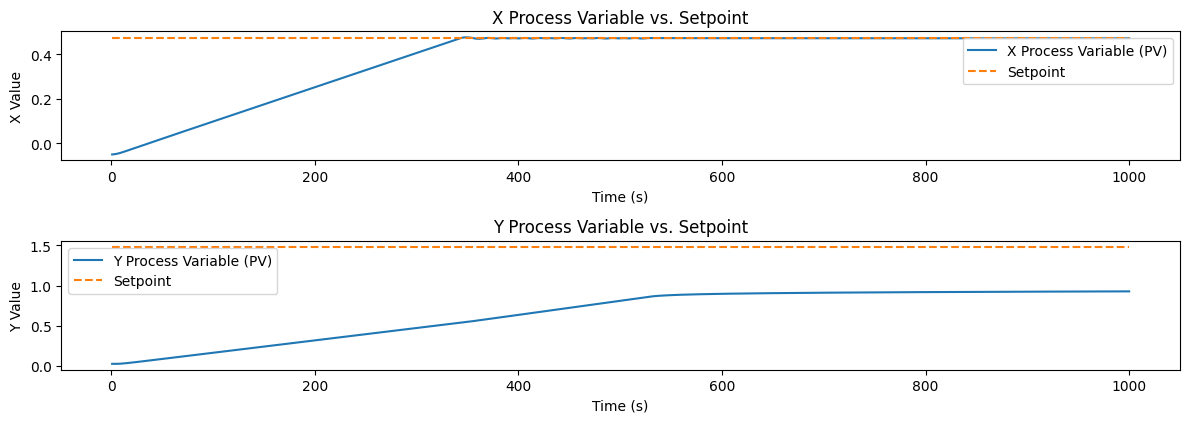

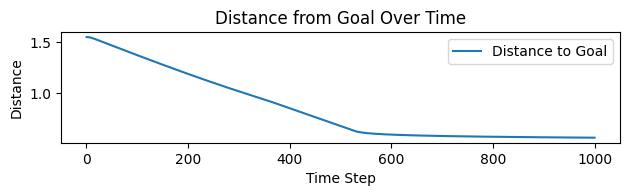

In [102]:
if __name__ == "__main__":
    main()